# Version 3.2 : RSF avec Optuna (Bayesian Optimization)

**Contexte** :
- **V2** (88 features): C-index = 0.7334
- **V3** (132 features): C-index = 0.7320
- **V3.1** (Grid search): En cours...

**Objectif** : Utiliser Optuna pour une recherche intelligente des hyperparamètres

**Avantages d'Optuna vs Grid Search** :
- ✅ **Bayesian optimization** : apprend des essais précédents
- ✅ **Pruning** : arrête les essais non prometteurs
- ✅ **Efficacité** : explore mieux avec moins d'essais
- ✅ **Distributions continues** : plus de flexibilité

**Améliorations** :
- 132 features complètes
- Feature interactions (top features)
- Optuna: 100-150 trials intelligents
- Objectif: C-index > 0.74

## 1. Setup & Installation

In [1]:
# Install Optuna if needed
# !pip install optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Optuna
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances

# Survival analysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")
print(f"Optuna version: {optuna.__version__}")

✓ Libraries imported
Optuna version: 4.6.0


## 2. Data Loading & Feature Engineering

In [2]:
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
clinical_test = pd.read_csv(f"{DATA_PATH}\\X_test\\clinical_test.csv")
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")
molecular_test = pd.read_csv(f"{DATA_PATH}\\X_test\\molecular_test.csv")

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")

✓ Data loaded: 3323 train patients


In [3]:
# Feature engineering functions (from V3)
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # Anomaly types
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    
    # Complexity
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] + cyto_features['cyto_other_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # Chromosomes
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    for chrom in chromosomes:
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    
    # Prognostic markers
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


In [4]:
# Create features
cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)

# Clean target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Clinical features
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

print(f"Clinical: {X_clinical.shape[1]} features")
print(f"Molecular: {mol_features_train.shape[1]} features")
print(f"Cytogenetic: {cyto_features_train.shape[1]} features")

Clinical: 28 features
Molecular: 60 features
Cytogenetic: 44 features


## 3. Feature Interactions (Quick Win)

Créer des interactions entre features importantes

In [5]:
# Combine base features
mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)

X_base = pd.concat([X_clinical, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

# Create interaction features
print("Creating feature interactions...")

X_interactions = X_base.copy()

# Ratio features
X_interactions['blast_to_wbc_ratio'] = X_base['BM_BLAST'] / (X_base['WBC'] + 1)
X_interactions['mutations_per_vaf'] = X_base['mutation_count_total'] / (X_base['vaf_mean'] + 0.01)
X_interactions['blast_to_plt_ratio'] = X_base['BM_BLAST'] / (X_base['PLT'] + 1)

# Key interactions (top features)
if 'vaf_mean' in X_base.columns and 'mutation_count_total' in X_base.columns:
    X_interactions['blast_x_mutations'] = X_base['BM_BLAST'] * X_base['mutation_count_total']
    X_interactions['blast_x_vaf'] = X_base['BM_BLAST'] * X_base['vaf_mean']
    X_interactions['vaf_x_mutations'] = X_base['vaf_mean'] * X_base['mutation_count_total']

# Cytogenetic interactions
if 'cyto_complex' in X_base.columns:
    X_interactions['blast_x_complex'] = X_base['BM_BLAST'] * X_base['cyto_complex']
    X_interactions['mutations_x_complex'] = X_base['mutation_count_total'] * X_base['cyto_complex']

# Log transforms for skewed features
for col in ['WBC', 'mutation_count_total', 'vaf_sum']:
    if col in X_base.columns:
        X_interactions[f'{col}_log'] = np.log1p(X_base[col])

print(f"✓ Features with interactions: {X_interactions.shape[1]} (added {X_interactions.shape[1] - X_base.shape[1]})")

Creating feature interactions...
✓ Features with interactions: 143 (added 11)


In [6]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_interactions),
    index=X_interactions.index,
    columns=X_interactions.columns
)

# Create survival target
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

print(f"✓ Final features: {X_imputed.shape[1]}")
print(f"✓ Target events: {y_surv['OS_STATUS'].sum()} / {len(y_surv)}")

✓ Final features: 143
✓ Target events: 1600 / 3173


In [7]:
# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y_surv, test_size=0.3, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"Train: {X_train.shape[0]} patients, {X_train.shape[1]} features")
print(f"Val: {X_val.shape[0]} patients")

Train: 2221 patients, 143 features
Val: 952 patients


## 4. Optuna Hyperparameter Optimization

In [8]:
# Define objective function
def objective(trial):
    """
    Optuna objective function to maximize C-index
    """
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 30),
        'max_features': trial.suggest_categorical('max_features', 
                                                  ['sqrt', 'log2', 0.2, 0.3, 0.4, 0.5]),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'n_jobs': -1,
        'random_state': 42,
        'verbose': 0
    }
    
    # Train model
    rsf = RandomSurvivalForest(**params)
    rsf.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred_val = rsf.predict(X_val)
    c_index = concordance_index_censored(
        y_val['OS_STATUS'], 
        y_val['OS_YEARS'], 
        y_pred_val
    )[0]
    
    return c_index

print("✓ Objective function defined")

✓ Objective function defined


In [9]:
print("="*60)
print("OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*60)

# Create study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)

# Optimize
start_time = time()
n_trials = 120

print(f"\nRunning {n_trials} trials with Bayesian optimization...")
print("This will take approximately 20-30 minutes...\n")

study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

elapsed_time = time() - start_time
print(f"\n✓ Optimization completed in {elapsed_time/60:.1f} minutes")
print(f"  Total trials: {len(study.trials)}")
print(f"  Completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"  Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

OPTUNA HYPERPARAMETER OPTIMIZATION

Running 120 trials with Bayesian optimization...
This will take approximately 20-30 minutes...



  0%|          | 0/120 [00:00<?, ?it/s]


✓ Optimization completed in 74.3 minutes
  Total trials: 120
  Completed trials: 120
  Pruned trials: 0


## 5. Optuna Results Analysis

In [10]:
# Best parameters
print("="*60)
print("BEST HYPERPARAMETERS (Optuna)")
print("="*60)

best_params = study.best_params
best_value = study.best_value

print(f"\nBest C-index: {best_value:.4f}\n")
print("Best parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nTrial #{study.best_trial.number}")

BEST HYPERPARAMETERS (Optuna)

Best C-index: 0.7370

Best parameters:
  n_estimators: 350
  min_samples_split: 27
  min_samples_leaf: 5
  max_features: 0.2
  max_depth: 23
  bootstrap: True

Trial #103


In [11]:
# Optimization history
fig = plot_optimization_history(study)
fig.update_layout(title="Optuna Optimization History")
fig.show()

print("\n✓ Optimization history plotted")


✓ Optimization history plotted


In [12]:
# Parameter importance
try:
    fig = plot_param_importances(study)
    fig.update_layout(title="Hyperparameter Importance")
    fig.show()
    print("✓ Parameter importance plotted")
except:
    print("⚠ Parameter importance requires at least 2 completed trials")

✓ Parameter importance plotted


In [13]:
# Top 10 trials
trials_df = study.trials_dataframe()
top_trials = trials_df.nlargest(10, 'value')[['number', 'value', 'params_n_estimators', 
                                                'params_min_samples_split', 'params_min_samples_leaf',
                                                'params_max_features', 'params_max_depth']]

print("\n" + "="*60)
print("TOP 10 TRIALS")
print("="*60)
print(top_trials.to_string(index=False))


TOP 10 TRIALS
 number    value  params_n_estimators  params_min_samples_split  params_min_samples_leaf params_max_features  params_max_depth
    103 0.737005                  350                        27                        5                 0.2                23
    104 0.736860                  300                        27                        5                 0.2                25
    111 0.736752                  250                        27                        5                 0.2                26
     95 0.736636                  450                        13                        5                 0.2                18
    112 0.736524                  300                        27                        5                 0.2                27
    108 0.736507                  300                        27                        5                 0.2                26
    109 0.736507                  300                        27                        5        

## 6. Final Optimized Model

In [14]:
print("="*60)
print("TRAINING FINAL OPTIMIZED MODEL")
print("="*60)

# Train with best parameters
rsf_optimized = RandomSurvivalForest(
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    max_depth=best_params['max_depth'],
    bootstrap=best_params['bootstrap'],
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rsf_optimized.fit(X_train, y_train)

TRAINING FINAL OPTIMIZED MODEL


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 350 out of 350 | elapsed:   16.2s finished


RandomSurvivalForest(max_depth=23, max_features=0.2, min_samples_leaf=5,
                     min_samples_split=27, n_estimators=350, n_jobs=-1,
                     random_state=42, verbose=1)

In [15]:
# Evaluate
y_pred_train_opt = rsf_optimized.predict(X_train)
y_pred_val_opt = rsf_optimized.predict(X_val)

c_index_train_opt = concordance_index_censored(
    y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train_opt
)[0]

c_index_val_opt = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_opt
)[0]

print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(f"Train C-index: {c_index_train_opt:.4f}")
print(f"Val C-index: {c_index_val_opt:.4f}")
print(f"Overfitting: {c_index_train_opt - c_index_val_opt:.4f}")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done 350 out of 350 | elapsed:    4.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.9s



FINAL MODEL PERFORMANCE
Train C-index: 0.8301
Val C-index: 0.7370
Overfitting: 0.0931


[Parallel(n_jobs=12)]: Done 350 out of 350 | elapsed:    1.8s finished


## 7. Version Comparison

In [16]:
print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame([
    {'Version': 'V2: Clinical + Molecular', 'Features': 88, 'C-index': 0.7334, 
     'Method': 'Default params'},
    {'Version': 'V3: + Cytogenetic', 'Features': 132, 'C-index': 0.7320, 
     'Method': 'Default params'},
    {'Version': 'V3.1: Grid Search', 'Features': 'Variable', 'C-index': 'TBD', 
     'Method': '144 configs'},
    {'Version': 'V3.2: Optuna + Interactions', 'Features': X_imputed.shape[1], 
     'C-index': c_index_val_opt, 'Method': f'{n_trials} Bayesian trials'}
])

print(comparison_df.to_string(index=False))

improvement_vs_v2 = (c_index_val_opt - 0.7334) * 100
improvement_vs_v3 = (c_index_val_opt - 0.7320) * 100

print(f"\n✓ Improvement vs V2: {improvement_vs_v2:+.2f}%")
print(f"✓ Improvement vs V3: {improvement_vs_v3:+.2f}%")

PERFORMANCE COMPARISON
                    Version Features   C-index              Method
   V2: Clinical + Molecular       88    0.7334      Default params
          V3: + Cytogenetic      132     0.732      Default params
          V3.1: Grid Search Variable       TBD         144 configs
V3.2: Optuna + Interactions      143  0.737005 120 Bayesian trials

✓ Improvement vs V2: +0.36%
✓ Improvement vs V3: +0.50%


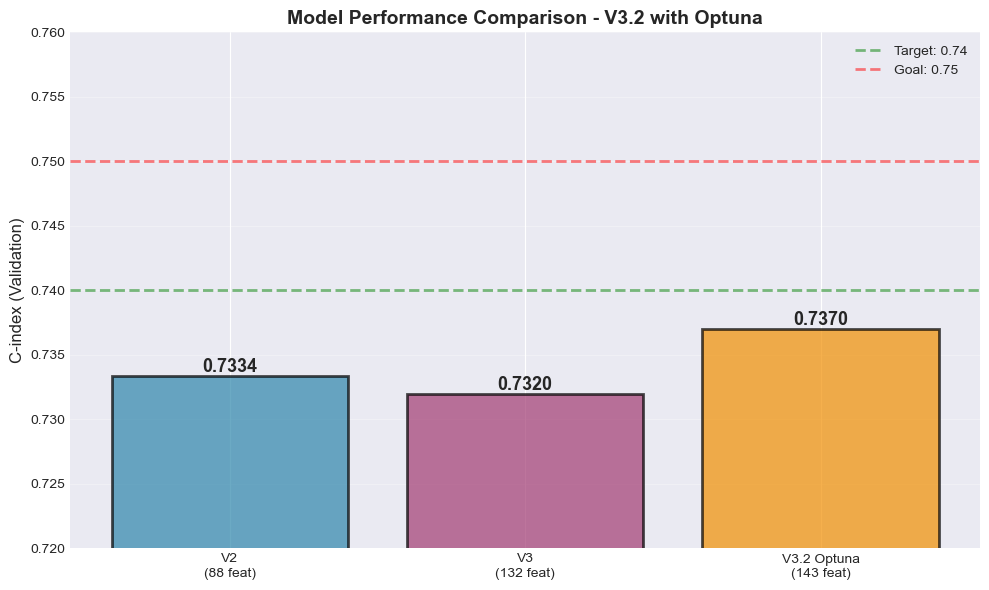

In [17]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

versions = ['V2\n(88 feat)', 'V3\n(132 feat)', f'V3.2 Optuna\n({X_imputed.shape[1]} feat)']
scores = [0.7334, 0.7320, c_index_val_opt]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = ax.bar(versions, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(y=0.74, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.74')
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Goal: 0.75')

ax.set_ylabel('C-index (Validation)', fontsize=12)
ax.set_title('Model Performance Comparison - V3.2 with Optuna', fontsize=14, fontweight='bold')
ax.set_ylim([0.72, max(0.76, c_index_val_opt + 0.01)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Test Set Preparation & Prediction

In [ ]:
print("="*60)
print("TEST SET PREPARATION")
print("="*60)

# Create features for test
cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

# Clinical features
clinical_test_indexed = clinical_test.set_index('ID')
X_numeric_test = clinical_test_indexed[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test_indexed['CENTER'], prefix='CENTER', drop_first=True)
for col in center_encoded.columns:
    if col not in center_encoded_test.columns:
        center_encoded_test[col] = 0
center_encoded_test = center_encoded_test[center_encoded.columns]
X_clinical_test = pd.concat([X_numeric_test, center_encoded_test], axis=1)

# Combine
mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_test_base = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

# Add same interactions
X_test_interactions = X_test_base.copy()
X_test_interactions['blast_to_wbc_ratio'] = X_test_base['BM_BLAST'] / (X_test_base['WBC'] + 1)
X_test_interactions['mutations_per_vaf'] = X_test_base['mutation_count_total'] / (X_test_base['vaf_mean'] + 0.01)
X_test_interactions['blast_to_plt_ratio'] = X_test_base['BM_BLAST'] / (X_test_base['PLT'] + 1)

if 'vaf_mean' in X_test_base.columns and 'mutation_count_total' in X_test_base.columns:
    X_test_interactions['blast_x_mutations'] = X_test_base['BM_BLAST'] * X_test_base['mutation_count_total']
    X_test_interactions['blast_x_vaf'] = X_test_base['BM_BLAST'] * X_test_base['vaf_mean']
    X_test_interactions['vaf_x_mutations'] = X_test_base['vaf_mean'] * X_test_base['mutation_count_total']

if 'cyto_complex' in X_test_base.columns:
    X_test_interactions['blast_x_complex'] = X_test_base['BM_BLAST'] * X_test_base['cyto_complex']
    X_test_interactions['mutations_x_complex'] = X_test_base['mutation_count_total'] * X_test_base['cyto_complex']

for col in ['WBC', 'mutation_count_total', 'vaf_sum']:
    if col in X_test_base.columns:
        X_test_interactions[f'{col}_log'] = np.log1p(X_test_base[col])

# Align columns
for col in X_interactions.columns:
    if col not in X_test_interactions.columns:
        X_test_interactions[col] = 0
X_test_interactions = X_test_interactions[X_interactions.columns]

# Impute
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_interactions),
    index=X_test_interactions.index,
    columns=X_test_interactions.columns
)

print(f"✓ Test set prepared: {X_test_imputed.shape}")

In [ ]:
# Retrain on full data
print("\nRetraining on full training set...")

rsf_final = RandomSurvivalForest(
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    max_depth=best_params['max_depth'],
    bootstrap=best_params['bootstrap'],
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rsf_final.fit(X_imputed, y_surv)
print("\n✓ Final model trained")

In [ ]:
# Predictions
predictions_test = rsf_final.predict(X_test_imputed)

submission = pd.DataFrame({
    'ID': X_test_imputed.index,
    'PRED': predictions_test
})

submission_path = f"{DATA_PATH}\\submission_rsf_optuna.csv"
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION GENERATED")
print("="*60)
print(f"File: {submission_path}")
print(f"Predictions: {len(submission)}")
print(f"\nStatistics:")
print(submission['PRED'].describe())

## 9. Summary

In [ ]:
print("="*60)
print("VERSION 3.2 - OPTUNA OPTIMIZATION SUMMARY")
print("="*60)

print("\n📊 RESULTS:")
print(f"  V2 baseline: 0.7334")
print(f"  V3 baseline: 0.7320")
print(f"  V3.2 Optuna: {c_index_val_opt:.4f}")

print("\n🔧 OPTIMIZATIONS:")
print(f"  1. Feature interactions: +{X_imputed.shape[1] - 132} features")
print(f"  2. Optuna Bayesian search: {n_trials} trials")
print(f"  3. Best hyperparameters:")
for param, value in list(best_params.items())[:6]:
    print(f"     - {param}: {value}")

print("\n📈 IMPROVEMENT:")
print(f"  vs V2: {improvement_vs_v2:+.2f}%")
print(f"  vs V3: {improvement_vs_v3:+.2f}%")

if c_index_val_opt >= 0.74:
    print("\n🎯 TARGET REACHED! (C-index ≥ 0.74)")
if c_index_val_opt >= 0.75:
    print("🏆 GOAL EXCEEDED! (C-index ≥ 0.75)")

print("\n✅ OUTPUT:")
print(f"  Submission: submission_rsf_optuna.csv")
print(f"  Features: {X_imputed.shape[1]}")
print(f"  Final C-index: {c_index_val_opt:.4f}")